### 25 Mpc/h

In [1]:
import caesar
import numpy as np
import matplotlib.pyplot as plt
import unyt

from functions import *
unit = 'Mpc/h'

# find file corresponding to redshift z=0.5
print(caesar.progen.z_to_snap(0.5))

# load file corresponding to redshift z=0.5
infile = 'data/m25n512_125.hdf5'
obj = caesar.load(infile)

yt : [INFO     ] 2024-06-13 06:25:09,805 Opening data/m25n512_125.hdf5


(125, 0.49043513253694404)


yt : [INFO     ] 2024-06-13 06:25:10,242 Found 261717 halos
yt : [INFO     ] 2024-06-13 06:25:10,875 Found 5246 galaxies


In [2]:
# interpolation
from scipy.interpolate import interp1d

# Original distribution
original_x = np.arange(9.95,12.35,0.1)  # Bin mid-points (stellar mass)
original_y = np.array([2,7,2,4,6,
                10,18,37,93,391,
                2656,13936,26446,23258,25919,
                16346,12119,6851,2678,1361,
                383,134,22,10,4])# Counts in each bin (Ngal)

# Compute the normalized cumulative sum, which will serve as the CDF
cdf = np.cumsum(original_y)
cdf = cdf / cdf[-1]  # Normalize to make it a proper CDF

# Create an interpolation function for the CDF
cdf_func = interp1d(original_x, cdf, kind='nearest', bounds_error=False, fill_value=(0, 1))

# get the PDF (probabilities)
pdf = np.diff(cdf, prepend=0) / np.diff(original_x, prepend=0)

# Create an interpolation function for the PDF
pdf_func = interp1d(original_x, pdf, kind='nearest', bounds_error=False, fill_value=(0, 0))

# get galaxy stellar masses
gal_stellar_mass = [[i,np.log10(i.masses["stellar"])] for i in obj.galaxies]
# New sample (continuous values)
new_sample = np.array([i[1] for i in gal_stellar_mass])

# Get the PDF values (probabilities) for each point in the new sample
probabilities = pdf_func(new_sample)
probabilities /= sum(probabilities) # to normalize

In [3]:
# Randomly select indices based on the defined probabilities
# N (full sample)
np.random.seed(0)
selected_indices = np.random.choice(len(new_sample), size=len(new_sample), p=probabilities)
sample1 = new_sample[selected_indices]
print(len(sample1))

# get the galaxies corresponding to full sample
gal_sample1 = [j[0] for j in gal_stellar_mass for i in sample1 if i == j[1]]
print(len(gal_sample1))

# get positions for full sample
pos_full = np.array([i.pos.to(unit) for i in gal_sample1])

# std normal distribution of random values added to each position
delta= 0.04

# new positions
boxsize = np.array([obj.simulation.boxsize.to(unit)])

np.random.seed(0)
new_pos_full = pos_full + (np.random.normal(0, delta, (len(gal_sample1),3)))*boxsize
for i in range(3): # periodic boundary
    new_pos_full[:,i][new_pos_full[:,i] < np.zeros(1)] = (
        (new_pos_full[:,i][new_pos_full[:,i] < np.zeros(1)]) % boxsize) + boxsize
    new_pos_full[:,i][new_pos_full[:,i] > boxsize] %= boxsize


new_gal_pos = [(gal_sample1[i], new_pos_full[i]) for i in range(len(gal_sample1))]

5246
5246


In [4]:
# get the galaxies ordered by color
gal2 = [[i,i.absmag["sdss_r"] - i.absmag["sdss_i"]] for i in gal_sample1]
sort_gal_prop2 = sorted(gal2, key=lambda x: x[1])
gal_sorted2 = [i[0] for i in sort_gal_prop2]

# get the bottom and top 25% ordered by color.
# create two samples (blue and red galaxies) 
limit = len(gal_sorted2)//4
less2 = gal_sorted2[:limit] #very blue
midless2 = gal_sorted2[limit:limit*2] #blue
midmore2 = gal_sorted2[limit*2:-limit] #red
more2 = gal_sorted2[-limit:] #very red
print(len(gal_sorted2))
print(len(more2))
print(len(midmore2))
print(len(midless2))
print(len(less2))
print()

# get the galaxies ordered by sSFR
gal3 = [[i,i.sfr / i.masses["stellar"]] for i in gal_sample1]
sort_gal_prop3 = sorted(gal3, key=lambda x: x[1])
gal_sorted3 = [i[0] for i in sort_gal_prop3]

# get the bottom and top 25% ordered by sSFR.
# create two samples (star forming and quenched galaxies) 
limit = len(gal_sorted3)//4
less3 = gal_sorted3[:limit] #quenched
midless3 = gal_sorted3[limit:limit*2] #quenched
midmore3 = gal_sorted3[limit*2:-limit] #star forming
more3 = gal_sorted3[-limit:] #star forming
#print(len(gal_sorted3))
#print(len(more3))
#print(len(midmore3))
#print(len(midless3))
#print(len(less3))
#print()

# get galaxies ordered by age
gal1 = [[i,i.ages["mass_weighted"]] for i in gal_sample1]
sort_gal_prop1 = sorted(gal1, key=lambda x: x[1])
gal_sorted1 = [i[0] for i in sort_gal_prop1]

# get the bottom and top 25% ordered by age.
# create two samples (old and young galaxies) 
limit = len(gal_sorted1)//4
less1 = gal_sorted1[:limit] #very young
midless1 = gal_sorted1[limit:limit*2] #young
midmore1 = gal_sorted1[limit*2:-limit] #old
more1 = gal_sorted1[-limit:] #very old
#print(len(gal_sorted1))
#print(len(more1))
#print(len(midmore1))
#print(len(midless1))
#print(len(less1))

5246
1311
1313
1311
1311



In [5]:
# projected 2pcf on z-axis
# Color-dependent

ptpcf_red_25 = calculate_projected_2pcf(
    data1= np.array([pos for gal,pos in new_gal_pos if gal in more2]),
    box_size= obj.simulation.boxsize,
    isprojection_axis= 2,
    binnumber=10
)
ptpcf_midred_25 = calculate_projected_2pcf(
    data1= np.array([pos for gal,pos in new_gal_pos if gal in midmore2]),
    box_size= obj.simulation.boxsize,
    isprojection_axis= 2,
    binnumber=10
)
ptpcf_midblue_25= calculate_projected_2pcf(
    data1= np.array([pos for gal,pos in new_gal_pos if gal in midless2]),
    box_size= obj.simulation.boxsize,
    isprojection_axis= 2,
    binnumber=10
)
ptpcf_blue_25= calculate_projected_2pcf(
    data1= np.array([pos for gal,pos in new_gal_pos if gal in less2]),
    box_size= obj.simulation.boxsize,
    isprojection_axis= 2,
    binnumber=10
)

# estimate the uncertainty using bootstrap
uncertain_red_25 = find_ptpcf_uncertainty_bootstrap(
    positions1= np.array([pos for gal,pos in new_gal_pos if gal in more2]),
    size_box= obj.simulation.boxsize,
    proj_ax= 2,
    number_bin= 10
)
uncertain_midred_25 = find_ptpcf_uncertainty_bootstrap(
    positions1= np.array([pos for gal,pos in new_gal_pos if gal in midmore2]),
    size_box= obj.simulation.boxsize,
    proj_ax= 2,
    number_bin= 10
)
uncertain_midblue_25 = find_ptpcf_uncertainty_bootstrap(
    positions1= np.array([pos for gal,pos in new_gal_pos if gal in midless2]),
    size_box= obj.simulation.boxsize,
    proj_ax= 2,
    number_bin= 10
)
uncertain_blue_25 = find_ptpcf_uncertainty_bootstrap(
    positions1= np.array([pos for gal,pos in new_gal_pos if gal in less2]),
    size_box= obj.simulation.boxsize,
    proj_ax= 2,
    number_bin= 10
)


# sSFR-dependent

ptpcf_starform_25 = calculate_projected_2pcf(
    data1= np.array([pos for gal,pos in new_gal_pos if gal in more3]),
    box_size= obj.simulation.boxsize,
    isprojection_axis= 2,
    binnumber=10
)
ptpcf_midstarform_25 = calculate_projected_2pcf(
    data1= np.array([pos for gal,pos in new_gal_pos if gal in midmore3]),
    box_size= obj.simulation.boxsize,
    isprojection_axis= 2,
    binnumber=10
)
ptpcf_midquenched_25 = calculate_projected_2pcf(
    data1= np.array([pos for gal,pos in new_gal_pos if gal in midless3]),
    box_size= obj.simulation.boxsize,
    isprojection_axis= 2,
    binnumber=10
)
ptpcf_quenched_25 = calculate_projected_2pcf(
    data1= np.array([pos for gal,pos in new_gal_pos if gal in less3]),
    box_size= obj.simulation.boxsize,
    isprojection_axis= 2,
    binnumber=10
)

# estimate the uncertainty using bootstrap
uncertain_starform_25 = find_ptpcf_uncertainty_bootstrap(
    positions1= np.array([pos for gal,pos in new_gal_pos if gal in more3]),
    size_box= obj.simulation.boxsize,
    proj_ax= 2,
    number_bin= 10
)
uncertain_midstarform_25 = find_ptpcf_uncertainty_bootstrap(
    positions1= np.array([pos for gal,pos in new_gal_pos if gal in midmore3]),
    size_box= obj.simulation.boxsize,
    proj_ax= 2,
    number_bin= 10
)
uncertain_midquenched_25 = find_ptpcf_uncertainty_bootstrap(
    positions1= np.array([pos for gal,pos in new_gal_pos if gal in midless3]),
    size_box= obj.simulation.boxsize,
    proj_ax= 2,
    number_bin= 10
)
uncertain_quenched_25 = find_ptpcf_uncertainty_bootstrap(
    positions1= np.array([pos for gal,pos in new_gal_pos if gal in less3]),
    size_box= obj.simulation.boxsize,
    proj_ax= 2,
    number_bin= 10
)


# Age-dependent

ptpcf_old_25 = calculate_projected_2pcf(
    data1= np.array([pos for gal,pos in new_gal_pos if gal in more1]),
    box_size= obj.simulation.boxsize,
    isprojection_axis= 2,
    binnumber=10
)
ptpcf_midold_25 = calculate_projected_2pcf(
    data1= np.array([pos for gal,pos in new_gal_pos if gal in midmore1]),
    box_size= obj.simulation.boxsize,
    isprojection_axis= 2,
    binnumber=10
)
ptpcf_midyoung_25 = calculate_projected_2pcf(
    data1= np.array([pos for gal,pos in new_gal_pos if gal in midless1]),
    box_size= obj.simulation.boxsize,
    isprojection_axis= 2,
    binnumber=10
)
ptpcf_young_25 = calculate_projected_2pcf(
    data1= np.array([pos for gal,pos in new_gal_pos if gal in less1]),
    box_size= obj.simulation.boxsize,
    isprojection_axis= 2,
    binnumber=10
)

# estimate the uncertainty using bootstrap
uncertain_old_25 = find_ptpcf_uncertainty_bootstrap(
    positions1= np.array([pos for gal,pos in new_gal_pos if gal in more1]),
    size_box= obj.simulation.boxsize,
    proj_ax= 2,
    number_bin= 10
)
uncertain_midold_25 = find_ptpcf_uncertainty_bootstrap(
    positions1= np.array([pos for gal,pos in new_gal_pos if gal in midmore1]),
    size_box= obj.simulation.boxsize,
    proj_ax= 2,
    number_bin= 10
)
uncertain_midyoung_25 = find_ptpcf_uncertainty_bootstrap(
    positions1= np.array([pos for gal,pos in new_gal_pos if gal in midless1]),
    size_box= obj.simulation.boxsize,
    proj_ax= 2,
    number_bin= 10
)
uncertain_young_25 = find_ptpcf_uncertainty_bootstrap(
    positions1= np.array([pos for gal,pos in new_gal_pos if gal in less1]),
    size_box= obj.simulation.boxsize,
    proj_ax= 2,
    number_bin= 10
)

### 50 Mpc/h

In [7]:
import caesar
import numpy as np
import matplotlib.pyplot as plt
import unyt

from functions import *
unit = 'Mpc/h'

# find file corresponding to redshift z=0.5
print(caesar.progen.z_to_snap(0.5))

# load file corresponding to redshift z=0.5
infile = 'data/m50n512_125.hdf5'
obj = caesar.load(infile)

yt : [INFO     ] 2024-06-13 06:27:22,308 Opening data/m50n512_125.hdf5


(125, 0.49043513253694404)


yt : [INFO     ] 2024-06-13 06:27:22,982 Found 61977 halos
yt : [INFO     ] 2024-06-13 06:27:23,595 Found 5685 galaxies


In [8]:
# interpolation
from scipy.interpolate import interp1d

# Original distribution
original_x = np.arange(9.95,12.35,0.1)  # Bin mid-points (stellar mass)
original_y = np.array([2,7,2,4,6,
                10,18,37,93,391,
                2656,13936,26446,23258,25919,
                16346,12119,6851,2678,1361,
                383,134,22,10,4])# Counts in each bin (Ngal)

# Compute the normalized cumulative sum, which will serve as the CDF
cdf = np.cumsum(original_y)
cdf = cdf / cdf[-1]  # Normalize to make it a proper CDF

# Create an interpolation function for the CDF
cdf_func = interp1d(original_x, cdf, kind='nearest', bounds_error=False, fill_value=(0, 1))

# get the PDF (probabilities)
pdf = np.diff(cdf, prepend=0) / np.diff(original_x, prepend=0)

# Create an interpolation function for the PDF
pdf_func = interp1d(original_x, pdf, kind='nearest', bounds_error=False, fill_value=(0, 0))

# get galaxy stellar masses
gal_stellar_mass = [[i,np.log10(i.masses["stellar"])] for i in obj.galaxies]
# New sample (continuous values)
new_sample = np.array([i[1] for i in gal_stellar_mass])

# Get the PDF values (probabilities) for each point in the new sample
probabilities = pdf_func(new_sample)
probabilities /= sum(probabilities) # to normalize

In [9]:
# Randomly select indices based on the defined probabilities
# N (full sample)
np.random.seed(0)
selected_indices = np.random.choice(len(new_sample), size=len(new_sample), p=probabilities)
sample1 = new_sample[selected_indices]
print(len(sample1))

# get the galaxies corresponding to full sample
gal_sample1 = [j[0] for j in gal_stellar_mass for i in sample1 if i == j[1]]
print(len(gal_sample1))

# get positions for full sample
pos_full = np.array([i.pos.to(unit) for i in gal_sample1])

# std normal distribution of random values added to each position
delta= 0.04

# new positions
boxsize = np.array([obj.simulation.boxsize.to(unit)])

np.random.seed(0)
new_pos_full = pos_full + (np.random.normal(0, delta, (len(gal_sample1),3)))*boxsize
for i in range(3): # periodic boundary
    new_pos_full[:,i][new_pos_full[:,i] < np.zeros(1)] = (
        (new_pos_full[:,i][new_pos_full[:,i] < np.zeros(1)]) % boxsize) + boxsize
    new_pos_full[:,i][new_pos_full[:,i] > boxsize] %= boxsize


new_gal_pos = [(gal_sample1[i], new_pos_full[i]) for i in range(len(gal_sample1))]

5685
5685


In [10]:
# get the galaxies ordered by color
gal2 = [[i,i.absmag["sdss_r"] - i.absmag["sdss_i"]] for i in gal_sample1]
sort_gal_prop2 = sorted(gal2, key=lambda x: x[1])
gal_sorted2 = [i[0] for i in sort_gal_prop2]

# get the bottom and top 25% ordered by color.
# create two samples (blue and red galaxies) 
limit = len(gal_sorted2)//4
less2 = gal_sorted2[:limit] #very blue
midless2 = gal_sorted2[limit:limit*2] #blue
midmore2 = gal_sorted2[limit*2:-limit] #red
more2 = gal_sorted2[-limit:] #very red
print(len(gal_sorted2))
print(len(more2))
print(len(midmore2))
print(len(midless2))
print(len(less2))
print()

# get the galaxies ordered by sSFR
gal3 = [[i,i.sfr / i.masses["stellar"]] for i in gal_sample1]
sort_gal_prop3 = sorted(gal3, key=lambda x: x[1])
gal_sorted3 = [i[0] for i in sort_gal_prop3]

# get the bottom and top 25% ordered by sSFR.
# create two samples (star forming and quenched galaxies) 
limit = len(gal_sorted3)//4
less3 = gal_sorted3[:limit] #quenched
midless3 = gal_sorted3[limit:limit*2] #quenched
midmore3 = gal_sorted3[limit*2:-limit] #star forming
more3 = gal_sorted3[-limit:] #star forming
#print(len(gal_sorted3))
#print(len(more3))
#print(len(midmore3))
#print(len(midless3))
#print(len(less3))
#print()

# get galaxies ordered by age
gal1 = [[i,i.ages["mass_weighted"]] for i in gal_sample1]
sort_gal_prop1 = sorted(gal1, key=lambda x: x[1])
gal_sorted1 = [i[0] for i in sort_gal_prop1]

# get the bottom and top 25% ordered by age.
# create two samples (old and young galaxies) 
limit = len(gal_sorted1)//4
less1 = gal_sorted1[:limit] #very young
midless1 = gal_sorted1[limit:limit*2] #young
midmore1 = gal_sorted1[limit*2:-limit] #old
more1 = gal_sorted1[-limit:] #very old
#print(len(gal_sorted1))#positions= np.array([i.pos.to(unit) for i in less1]),
    
#print(len(more1))
#print(len(midmore1))
#print(len(midless1))
#print(len(less1))

5685
1421
1422
1421
1421



In [11]:
# projected 2pcf on z-axis
# Color-dependent

ptpcf_red_50 = calculate_projected_2pcf(
    data1= np.array([pos for gal,pos in new_gal_pos if gal in more2]),
    box_size= obj.simulation.boxsize,
    isprojection_axis= 2,
    binnumber=10
)
ptpcf_midred_50 = calculate_projected_2pcf(
    data1= np.array([pos for gal,pos in new_gal_pos if gal in midmore2]),
    box_size= obj.simulation.boxsize,
    isprojection_axis= 2,
    binnumber=10
)
ptpcf_midblue_50= calculate_projected_2pcf(
    data1= np.array([pos for gal,pos in new_gal_pos if gal in midless2]),
    box_size= obj.simulation.boxsize,
    isprojection_axis= 2,
    binnumber=10
)
ptpcf_blue_50= calculate_projected_2pcf(
    data1= np.array([pos for gal,pos in new_gal_pos if gal in less2]),
    box_size= obj.simulation.boxsize,
    isprojection_axis= 2,
    binnumber=10
)

# estimate the uncertainty using bootstrap
uncertain_red_50 = find_ptpcf_uncertainty_bootstrap(
    positions1= np.array([pos for gal,pos in new_gal_pos if gal in more2]),
    size_box= obj.simulation.boxsize,
    proj_ax= 2,
    number_bin= 10
)
uncertain_midred_50 = find_ptpcf_uncertainty_bootstrap(
    positions1= np.array([pos for gal,pos in new_gal_pos if gal in midmore2]),
    size_box= obj.simulation.boxsize,
    proj_ax= 2,
    number_bin= 10
)
uncertain_midblue_50 = find_ptpcf_uncertainty_bootstrap(
    positions1= np.array([pos for gal,pos in new_gal_pos if gal in midless2]),
    size_box= obj.simulation.boxsize,
    proj_ax= 2,
    number_bin= 10
)
uncertain_blue_50 = find_ptpcf_uncertainty_bootstrap(
    positions1= np.array([pos for gal,pos in new_gal_pos if gal in less2]),
    size_box= obj.simulation.boxsize,
    proj_ax= 2,
    number_bin= 10
)


# sSFR-dependent

ptpcf_starform_50 = calculate_projected_2pcf(
    data1= np.array([pos for gal,pos in new_gal_pos if gal in more3]),
    box_size= obj.simulation.boxsize,
    isprojection_axis= 2,
    binnumber=10
)
ptpcf_midstarform_50 = calculate_projected_2pcf(
    data1= np.array([pos for gal,pos in new_gal_pos if gal in midmore3]),
    box_size= obj.simulation.boxsize,
    isprojection_axis= 2,
    binnumber=10
)
ptpcf_midquenched_50 = calculate_projected_2pcf(
    data1= np.array([pos for gal,pos in new_gal_pos if gal in midless3]),
    box_size= obj.simulation.boxsize,
    isprojection_axis= 2,
    binnumber=10
)
ptpcf_quenched_50 = calculate_projected_2pcf(
    data1= np.array([pos for gal,pos in new_gal_pos if gal in less3]),
    box_size= obj.simulation.boxsize,
    isprojection_axis= 2,
    binnumber=10
)

# estimate the uncertainty using bootstrap
uncertain_starform_50 = find_ptpcf_uncertainty_bootstrap(
    positions1= np.array([pos for gal,pos in new_gal_pos if gal in more3]),
    size_box= obj.simulation.boxsize,
    proj_ax= 2,
    number_bin= 10
)
uncertain_midstarform_50 = find_ptpcf_uncertainty_bootstrap(
    positions1= np.array([pos for gal,pos in new_gal_pos if gal in midmore3]),
    size_box= obj.simulation.boxsize,
    proj_ax= 2,
    number_bin= 10
)
uncertain_midquenched_50 = find_ptpcf_uncertainty_bootstrap(
    positions1= np.array([pos for gal,pos in new_gal_pos if gal in midless3]),
    size_box= obj.simulation.boxsize,
    proj_ax= 2,
    number_bin= 10
)
uncertain_quenched_50 = find_ptpcf_uncertainty_bootstrap(
    positions1= np.array([pos for gal,pos in new_gal_pos if gal in less3]),
    size_box= obj.simulation.boxsize,
    proj_ax= 2,
    number_bin= 10
)


# Age-dependent

ptpcf_old_50 = calculate_projected_2pcf(
    data1= np.array([pos for gal,pos in new_gal_pos if gal in more1]),
    box_size= obj.simulation.boxsize,
    isprojection_axis= 2,
    binnumber=10
)
ptpcf_midold_50 = calculate_projected_2pcf(
    data1= np.array([pos for gal,pos in new_gal_pos if gal in midmore1]),
    box_size= obj.simulation.boxsize,
    isprojection_axis= 2,
    binnumber=10
)
ptpcf_midyoung_50 = calculate_projected_2pcf(
    data1= np.array([pos for gal,pos in new_gal_pos if gal in midless1]),
    box_size= obj.simulation.boxsize,
    isprojection_axis= 2,
    binnumber=10
)
ptpcf_young_50 = calculate_projected_2pcf(
    data1= np.array([pos for gal,pos in new_gal_pos if gal in less1]),
    box_size= obj.simulation.boxsize,
    isprojection_axis= 2,
    binnumber=10
)

# estimate the uncertainty using bootstrap
uncertain_old_50 = find_ptpcf_uncertainty_bootstrap(
    positions1= np.array([pos for gal,pos in new_gal_pos if gal in more1]),
    size_box= obj.simulation.boxsize,
    proj_ax= 2,
    number_bin= 10
)
uncertain_midold_50 = find_ptpcf_uncertainty_bootstrap(
    positions1= np.array([pos for gal,pos in new_gal_pos if gal in midmore1]),
    size_box= obj.simulation.boxsize,
    proj_ax= 2,
    number_bin= 10
)
uncertain_midyoung_50 = find_ptpcf_uncertainty_bootstrap(
    positions1= np.array([pos for gal,pos in new_gal_pos if gal in midless1]),
    size_box= obj.simulation.boxsize,
    proj_ax= 2,
    number_bin= 10
)
uncertain_young_50 = find_ptpcf_uncertainty_bootstrap(
    positions1= np.array([pos for gal,pos in new_gal_pos if gal in less1]),
    size_box= obj.simulation.boxsize,
    proj_ax= 2,
    number_bin= 10
)

### 100 Mpc/h

In [12]:
import caesar
import numpy as np
import matplotlib.pyplot as plt
import unyt

from functions import *
unit = 'Mpc/h'

# find file corresponding to redshift z=0.5
print(caesar.progen.z_to_snap(0.5))

# load file corresponding to redshift z=0.5
infile = 'data/m100n1024_125.hdf5'
obj = caesar.load(infile)

yt : [INFO     ] 2024-06-13 06:28:48,442 Opening data/m100n1024_125.hdf5


(125, 0.49043513253694404)


yt : [INFO     ] 2024-06-13 06:28:49,132 Found 501820 halos
yt : [INFO     ] 2024-06-13 06:28:50,285 Found 45349 galaxies


In [13]:
# interpolation
from scipy.interpolate import interp1d

# Original distribution
original_x = np.arange(9.95,12.35,0.1)  # Bin mid-points (stellar mass)
original_y = np.array([2,7,2,4,6,
                10,18,37,93,391,
                2656,13936,26446,23258,25919,
                16346,12119,6851,2678,1361,
                383,134,22,10,4])# Counts in each bin (Ngal)

# Compute the normalized cumulative sum, which will serve as the CDF
cdf = np.cumsum(original_y)
cdf = cdf / cdf[-1]  # Normalize to make it a proper CDF

# Create an interpolation function for the CDF
cdf_func = interp1d(original_x, cdf, kind='nearest', bounds_error=False, fill_value=(0, 1))

# get the PDF (probabilities)
pdf = np.diff(cdf, prepend=0) / np.diff(original_x, prepend=0)

# Create an interpolation function for the PDF
pdf_func = interp1d(original_x, pdf, kind='nearest', bounds_error=False, fill_value=(0, 0))

# get galaxy stellar masses
gal_stellar_mass = [[i,np.log10(i.masses["stellar"])] for i in obj.galaxies]
# New sample (continuous values)
new_sample = np.array([i[1] for i in gal_stellar_mass])

# Get the PDF values (probabilities) for each point in the new sample
probabilities = pdf_func(new_sample)
probabilities /= sum(probabilities) # to normalize

In [14]:
# Randomly select indices based on the defined probabilities
# N (full sample)
np.random.seed(0)
selected_indices = np.random.choice(len(new_sample), size=len(new_sample), p=probabilities)
sample1 = new_sample[selected_indices]
print(len(sample1))

# get the galaxies corresponding to full sample
gal_sample1 = [j[0] for j in gal_stellar_mass for i in sample1 if i == j[1]]
print(len(gal_sample1))

# get positions for full sample
pos_full = np.array([i.pos.to(unit) for i in gal_sample1])

# std normal distribution of random values added to each position
delta= 0.04

# new positions
boxsize = np.array([obj.simulation.boxsize.to(unit)])

np.random.seed(0)
new_pos_full = pos_full + (np.random.normal(0, delta, (len(gal_sample1),3)))*boxsize
for i in range(3): # periodic boundary
    new_pos_full[:,i][new_pos_full[:,i] < np.zeros(1)] = (
        (new_pos_full[:,i][new_pos_full[:,i] < np.zeros(1)]) % boxsize) + boxsize
    new_pos_full[:,i][new_pos_full[:,i] > boxsize] %= boxsize


new_gal_pos = [(gal_sample1[i], new_pos_full[i]) for i in range(len(gal_sample1))]

45349
45349


In [15]:
# get the galaxies ordered by color
gal2 = [[i,i.absmag["sdss_r"] - i.absmag["sdss_i"]] for i in gal_sample1]
sort_gal_prop2 = sorted(gal2, key=lambda x: x[1])
gal_sorted2 = [i[0] for i in sort_gal_prop2]

# get the bottom and top 25% ordered by color.
# create two samples (blue and red galaxies) 
limit = len(gal_sorted2)//4
less2 = gal_sorted2[:limit] #very blue
midless2 = gal_sorted2[limit:limit*2] #blue
midmore2 = gal_sorted2[limit*2:-limit] #red
more2 = gal_sorted2[-limit:] #very red
print(len(gal_sorted2))
print(len(more2))
print(len(midmore2))
print(len(midless2))
print(len(less2))
print()

# get the galaxies ordered by sSFR
gal3 = [[i,i.sfr / i.masses["stellar"]] for i in gal_sample1]
sort_gal_prop3 = sorted(gal3, key=lambda x: x[1])
gal_sorted3 = [i[0] for i in sort_gal_prop3]

# get the bottom and top 25% ordered by sSFR.
# create two samples (star forming and quenched galaxies) 
limit = len(gal_sorted3)//4
less3 = gal_sorted3[:limit] #quenched
midless3 = gal_sorted3[limit:limit*2] #quenched
midmore3 = gal_sorted3[limit*2:-limit] #star forming
more3 = gal_sorted3[-limit:] #star forming
#print(len(gal_sorted3))
#print(len(more3))
#print(len(midmore3))
#print(len(midless3))
#print(len(less3))
#print()

# get galaxies ordered by age
gal1 = [[i,i.ages["mass_weighted"]] for i in gal_sample1]
sort_gal_prop1 = sorted(gal1, key=lambda x: x[1])
gal_sorted1 = [i[0] for i in sort_gal_prop1]

# get the bottom and top 25% ordered by age.
# create two samples (old and young galaxies) 
limit = len(gal_sorted1)//4
less1 = gal_sorted1[:limit] #very young
midless1 = gal_sorted1[limit:limit*2] #young
midmore1 = gal_sorted1[limit*2:-limit] #old
more1 = gal_sorted1[-limit:] #very old
#print(len(gal_sorted1))
#print(len(more1))
#print(len(midmore1))
#rint(len(midless1))
#print(len(less1))

45349
11337
11338
11337
11337



In [16]:
# projected 2pcf with bootstrap uncertainty

# Color-dependent
ptpcf_red_100 = calculate_projected_2pcf_split(
    large_positions= np.array([pos for gal,pos in new_gal_pos if gal in more2]),
    boxsize= obj.simulation.boxsize,
    binnum=10,
    N=10
)
ptpcf_midred_100 = calculate_projected_2pcf_split(
    large_positions= np.array([pos for gal,pos in new_gal_pos if gal in midmore2]),
    boxsize= obj.simulation.boxsize,
    binnum=10,
    N=10
)
ptpcf_midblue_100 = calculate_projected_2pcf_split(
    large_positions= np.array([pos for gal,pos in new_gal_pos if gal in midless2]),
    boxsize= obj.simulation.boxsize,
    binnum=10,
    N=10
)
ptpcf_blue_100 = calculate_projected_2pcf_split(
    large_positions= np.array([pos for gal,pos in new_gal_pos if gal in less2]),
    boxsize= obj.simulation.boxsize,
    binnum=10,
    N=10
)

# sSFR-dependent
ptpcf_starform_100 = calculate_projected_2pcf_split(
    large_positions= np.array([pos for gal,pos in new_gal_pos if gal in more3]),
    boxsize= obj.simulation.boxsize,
    binnum=10,
    N=10
)
ptpcf_midstarform_100 = calculate_projected_2pcf_split(
    large_positions= np.array([pos for gal,pos in new_gal_pos if gal in midmore3]),
    boxsize= obj.simulation.boxsize,
    binnum=10,
    N=10
)
ptpcf_midquenched_100 = calculate_projected_2pcf_split(
    large_positions= np.array([pos for gal,pos in new_gal_pos if gal in midless3]),
    boxsize= obj.simulation.boxsize,
    binnum=10,
    N=10
)
ptpcf_quenched_100 = calculate_projected_2pcf_split(
    large_positions= np.array([pos for gal,pos in new_gal_pos if gal in less3]),
    boxsize= obj.simulation.boxsize,
    binnum=10,
    N=10
)

# Age-dependent
ptpcf_old_100 = calculate_projected_2pcf_split(
    large_positions= np.array([pos for gal,pos in new_gal_pos if gal in more1]),
    boxsize= obj.simulation.boxsize,
    binnum=10,
    N=10
)
ptpcf_midold_100 = calculate_projected_2pcf_split(
    large_positions= np.array([pos for gal,pos in new_gal_pos if gal in midmore1]),
    boxsize= obj.simulation.boxsize,
    binnum=10,
    N=10
)
ptpcf_midyoung_100 = calculate_projected_2pcf_split(
    large_positions= np.array([pos for gal,pos in new_gal_pos if gal in midless1]),
    boxsize= obj.simulation.boxsize,
    binnum=10,
    N=10
)
ptpcf_young_100 = calculate_projected_2pcf_split(
    large_positions= np.array([pos for gal,pos in new_gal_pos if gal in less1]),
    boxsize= obj.simulation.boxsize,
    binnum=10,
    N=10
)

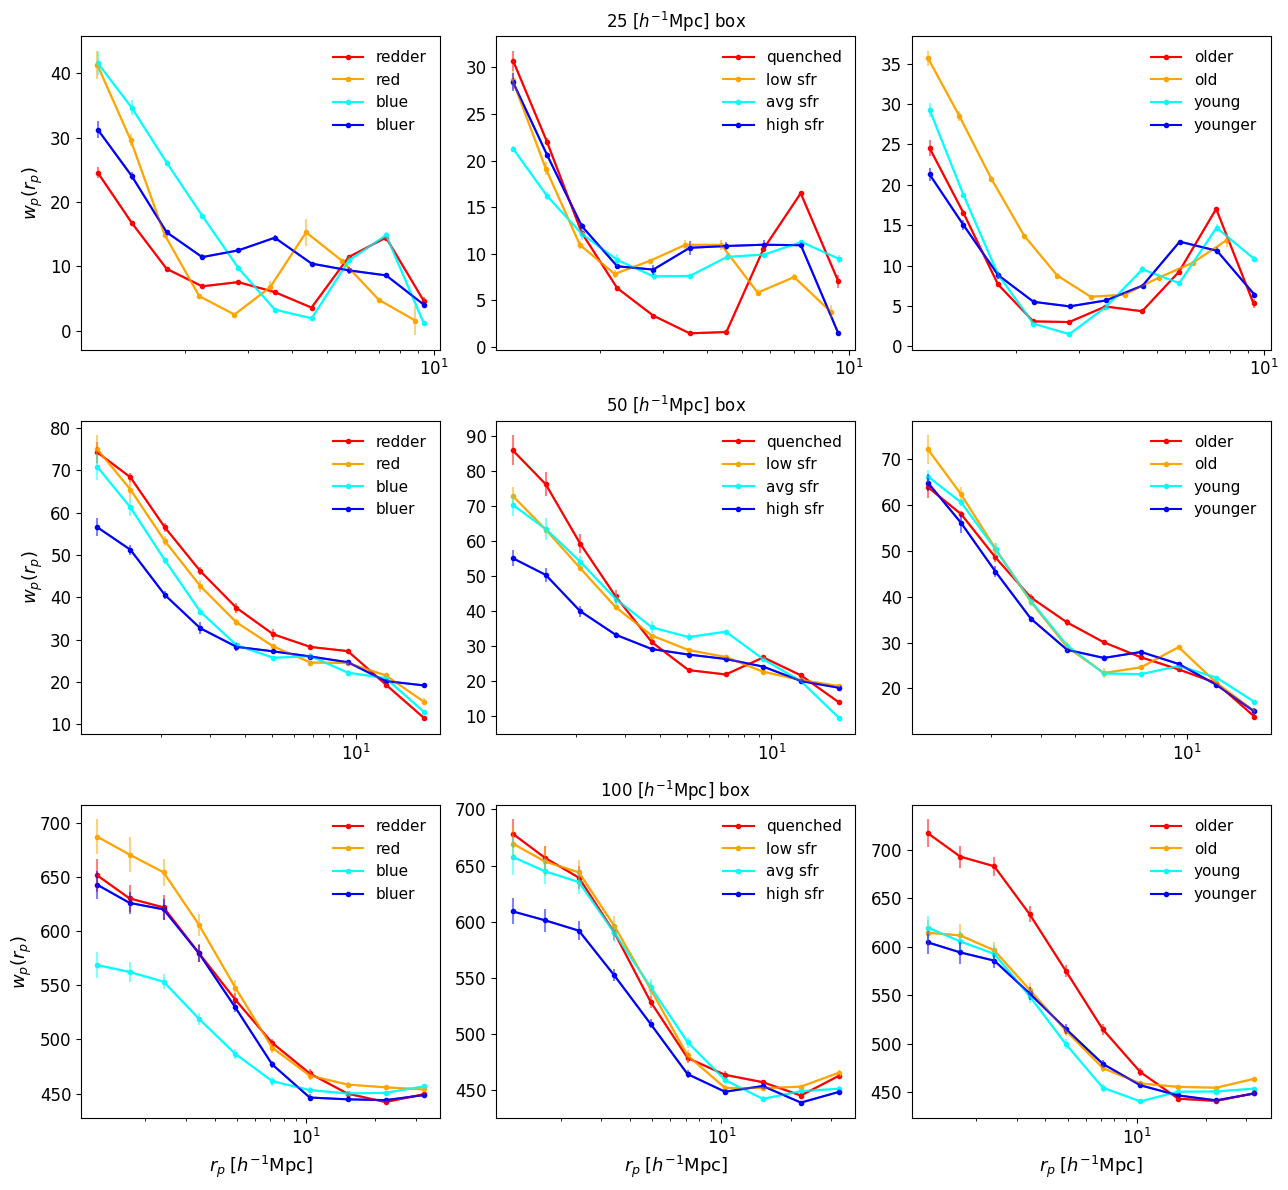

In [17]:
# plot
fig,ax = plt.subplots(3,3, figsize=(13, 12))
#fig.subplots_adjust(hspace=0)
#fig.subplots_adjust(wspace=0)

# 25 Mpc/h box
# color
ax[0,0].plot(ptpcf_red_25[0],ptpcf_red_25[1], marker = '.',color= 'Red', label = 'redder')
ax[0,0].plot(ptpcf_midred_25[0],ptpcf_midred_25[1], marker = '.', color= 'Orange', label = 'red')
ax[0,0].plot(ptpcf_midblue_25[0],ptpcf_midblue_25[1], marker = '.',color= 'Cyan', label = 'blue')
ax[0,0].plot(ptpcf_blue_25[0],ptpcf_blue_25[1], marker = '.', color= 'Blue', label = 'bluer')

ax[0,0].errorbar(ptpcf_red_25[0], ptpcf_red_25[1], yerr=uncertain_red_25[1], color= 'Red', alpha = .5)
ax[0,0].errorbar(ptpcf_midred_25[0], ptpcf_midred_25[1], yerr=uncertain_midred_25[1], color= 'Orange', alpha = .5)
ax[0,0].errorbar(ptpcf_midblue_25[0], ptpcf_midblue_25[1], yerr=uncertain_midblue_25[1], color= 'Cyan', alpha = .5)
ax[0,0].errorbar(ptpcf_blue_25[0], ptpcf_blue_25[1], yerr=uncertain_blue_25[1], color= 'Blue', alpha = .5)

#ax[0,0].set_xlabel(r"$r_{p} \; [h^{-1} \mathrm{Mpc}]$", fontsize=13)
ax[0,0].set_ylabel(r"$w_{p} (r_{p})$", fontsize=13)
#ax[0,0].set_title(r'25 $[h^{-1} \mathrm{Mpc}]$ box', fontsize=11)
#ax[0,0].set_ylim(0,2.5)
#ax[0,0].set_xlim(10e-1,10**(1.3))
#ax[0,0].set_yticks(np.arange(0,50,10))
ax[0,0].set_xscale('log')
ax[0,0].legend(fontsize=11, frameon=False)
#ax[0,0].text(10**(0.2), 42, r'25 $[h^{-1} \mathrm{Mpc}]$ box',fontsize=11)

# ssfr
ax[0,1].plot(ptpcf_quenched_25[0],ptpcf_quenched_25[1], marker = '.', color= 'Red', label = 'quenched')
ax[0,1].plot(ptpcf_midquenched_25[0],ptpcf_midquenched_25[1], marker = '.', color= 'Orange', label = 'low sfr')
ax[0,1].plot(ptpcf_midstarform_25[0],ptpcf_midstarform_25[1], marker = '.', color= 'Cyan', label = 'avg sfr')
ax[0,1].plot(ptpcf_starform_25[0],ptpcf_starform_25[1], marker = '.', color= 'Blue', label = 'high sfr')

ax[0,1].errorbar(ptpcf_quenched_25[0], ptpcf_quenched_25[1], yerr=uncertain_quenched_25[1], color= 'Red', alpha = .5)
ax[0,1].errorbar(ptpcf_midquenched_25[0], ptpcf_midquenched_25[1], yerr=uncertain_midquenched_25[1], color= 'Orange', alpha = .5)
ax[0,1].errorbar(ptpcf_midstarform_25[0], ptpcf_midstarform_25[1], yerr=uncertain_midstarform_25[1], color= 'Cyan', alpha = .5)
ax[0,1].errorbar(ptpcf_starform_25[0], ptpcf_starform_25[1], yerr=uncertain_starform_25[1], color= 'Blue', alpha = .5)

#ax[0,1].set_xlabel(r"$r_{p} \; [h^{-1} \mathrm{Mpc}]$",fontsize=13)
#ax[0,1].set_ylabel(r"$w_{p} (r_{p})$",fontsize=13)
ax[0,1].set_title(r'25 $[h^{-1} \mathrm{Mpc}]$ box', fontsize=12)
#ax[0,1].set_ylim(0,2.5)
#ax[0,1].set_xlim(10e-1,10**(1.3))
#ax[0,1].set_yticks(np.arange(0,55,10))
ax[0,1].set_xscale('log')
ax[0,1].legend(fontsize=11, frameon=False)

# age
ax[0,2].plot(ptpcf_old_25[0],ptpcf_old_25[1], marker = '.', color= 'Red', label = 'older')
ax[0,2].plot(ptpcf_midold_25[0],ptpcf_midold_25[1], marker = '.', color= 'Orange', label = 'old')
ax[0,2].plot(ptpcf_midyoung_25[0],ptpcf_midyoung_25[1], marker = '.', color= 'Cyan', label = 'young')
ax[0,2].plot(ptpcf_young_25[0],ptpcf_young_25[1], marker = '.', color= 'Blue', label = 'younger')

ax[0,2].errorbar(ptpcf_old_25[0], ptpcf_old_25[1], yerr=uncertain_old_25[1], color= 'Red', alpha = .5)
ax[0,2].errorbar(ptpcf_midold_25[0], ptpcf_midold_25[1], yerr=uncertain_midold_25[1], color= 'Orange', alpha = .5)
ax[0,2].errorbar(ptpcf_midyoung_25[0], ptpcf_midyoung_25[1], yerr=uncertain_midyoung_25[1], color= 'Cyan', alpha = .5)
ax[0,2].errorbar(ptpcf_young_25[0], ptpcf_young_25[1], yerr=uncertain_young_25[1], color= 'Blue', alpha = .5)

#ax[0,2].set_xlabel(r"$r_{p} \; [h^{-1} \mathrm{Mpc}]$", fontsize=13)
#ax[0,2].set_ylabel(r"$w_{p} (r_{p})$", fontsize=13)
#ax[0,2].set_title('projected 2pcf', fontsize=11)
#ax[0,2].set_ylim(15,70)
#ax[0,2].set_xlim(10e-1,10**(0.1))
#ax[0,2].set_yticks(np.arange(0,50,10))
ax[0,2].set_xscale('log')
ax[0,2].legend(fontsize=11, frameon=False)


# 50 Mpc/h
# color
ax[1,0].plot(ptpcf_red_50[0],ptpcf_red_50[1], marker = '.',color= 'Red', label = 'redder')
ax[1,0].plot(ptpcf_midred_50[0],ptpcf_midred_50[1], marker = '.', color= 'Orange', label = 'red')
ax[1,0].plot(ptpcf_midblue_50[0],ptpcf_midblue_50[1], marker = '.',color= 'Cyan', label = 'blue')
ax[1,0].plot(ptpcf_blue_50[0],ptpcf_blue_50[1], marker = '.', color= 'Blue', label = 'bluer')

ax[1,0].errorbar(ptpcf_red_50[0], ptpcf_red_50[1], yerr=uncertain_red_50[1], color= 'Red', alpha = .5)
ax[1,0].errorbar(ptpcf_midred_50[0], ptpcf_midred_50[1], yerr=uncertain_midred_50[1], color= 'Orange', alpha = .5)
ax[1,0].errorbar(ptpcf_midblue_50[0], ptpcf_midblue_50[1], yerr=uncertain_midblue_50[1], color= 'Cyan', alpha = .5)
ax[1,0].errorbar(ptpcf_blue_50[0], ptpcf_blue_50[1], yerr=uncertain_blue_50[1], color= 'Blue', alpha = .5)

#ax[1,0].set_xlabel(r"$r_{p} \; [h^{-1} \mathrm{Mpc}]$", fontsize=13)
ax[1,0].set_ylabel(r"$w_{p} (r_{p})$", fontsize=13)
#ax[1,0].set_title('projected tpcf', fontsize=11)
#ax[1,0].set_ylim(0,2.5)
#ax[1,0].set_xlim(10e-1,10**(1.3))
#ax[1,0].set_yticks(np.arange(0,50,10))
ax[1,0].set_xscale('log')
ax[1,0].legend(fontsize=11, frameon=False)

# ssfr
ax[1,1].plot(ptpcf_quenched_50[0],ptpcf_quenched_50[1], marker = '.', color= 'Red', label = 'quenched')
ax[1,1].plot(ptpcf_midquenched_50[0],ptpcf_midquenched_50[1], marker = '.', color= 'Orange', label = 'low sfr')
ax[1,1].plot(ptpcf_midstarform_50[0],ptpcf_midstarform_50[1], marker = '.', color= 'Cyan', label = 'avg sfr')
ax[1,1].plot(ptpcf_starform_50[0],ptpcf_starform_50[1], marker = '.', color= 'Blue', label = 'high sfr')

ax[1,1].errorbar(ptpcf_quenched_50[0], ptpcf_quenched_50[1], yerr=uncertain_quenched_50[1], color= 'Red', alpha = .5)
ax[1,1].errorbar(ptpcf_midquenched_50[0], ptpcf_midquenched_50[1], yerr=uncertain_midquenched_50[1], color= 'Orange', alpha = .5)
ax[1,1].errorbar(ptpcf_midstarform_50[0], ptpcf_midstarform_50[1], yerr=uncertain_midstarform_50[1], color= 'Cyan', alpha = .5)
ax[1,1].errorbar(ptpcf_starform_50[0], ptpcf_starform_50[1], yerr=uncertain_starform_50[1], color= 'Blue', alpha = .5)

#ax[1,1].set_xlabel(r"$r_{p} \; [h^{-1} \mathrm{Mpc}]$",fontsize=13)
#ax[1,1].set_ylabel(r"$w_{p} (r_{p})$",fontsize=13)
ax[1,1].set_title(r'50 $[h^{-1} \mathrm{Mpc}]$ box', fontsize=12)
#ax[1,1].set_ylim(0,2.5)
#ax[1,1].set_xlim(10e-1,10**(1.3))
#ax[1,1].set_yticks(np.arange(0,55,10))
ax[1,1].set_xscale('log')
ax[1,1].legend(fontsize=11, frameon=False)

# age
ax[1,2].plot(ptpcf_old_50[0],ptpcf_old_50[1], marker = '.', color= 'Red', label = 'older')
ax[1,2].plot(ptpcf_midold_50[0],ptpcf_midold_50[1], marker = '.', color= 'Orange', label = 'old')
ax[1,2].plot(ptpcf_midyoung_50[0],ptpcf_midyoung_50[1], marker = '.', color= 'Cyan', label = 'young')
ax[1,2].plot(ptpcf_young_50[0],ptpcf_young_50[1], marker = '.', color= 'Blue', label = 'younger')

ax[1,2].errorbar(ptpcf_old_50[0], ptpcf_old_50[1], yerr=uncertain_old_50[1], color= 'Red', alpha = .5)
ax[1,2].errorbar(ptpcf_midold_50[0], ptpcf_midold_50[1], yerr=uncertain_midold_50[1], color= 'Orange', alpha = .5)
ax[1,2].errorbar(ptpcf_midyoung_50[0], ptpcf_midyoung_50[1], yerr=uncertain_midyoung_50[1], color= 'Cyan', alpha = .5)
ax[1,2].errorbar(ptpcf_young_50[0], ptpcf_young_50[1], yerr=uncertain_young_50[1], color= 'Blue', alpha = .5)

#ax[1,2].set_xlabel(r"$r_{p} \; [h^{-1} \mathrm{Mpc}]$", fontsize=13)
#ax[1,2].set_ylabel(r"$w_{p} (r_{p})$", fontsize=13)
#ax[1,2].set_title('projected 2pcf', fontsize=11)
#ax[1,2].set_ylim(15,70)
#ax[1,2].set_xlim(10e-1,10**(0.1))
#ax[1,2].set_yticks(np.arange(0,50,10))
ax[1,2].set_xscale('log')
ax[1,2].legend(fontsize=11, frameon=False)


# 100 Mpc/h
# color
ax[2,0].plot(ptpcf_red_100[0], ptpcf_red_100[1], marker = '.', color= 'Red', label = 'redder')
ax[2,0].plot(ptpcf_midred_100[0], ptpcf_midred_100[1], marker = '.', color= 'Orange', label = 'red')
ax[2,0].plot(ptpcf_midblue_100[0], ptpcf_midblue_100[1], marker = '.', color= 'Cyan', label = 'blue')
ax[2,0].plot(ptpcf_blue_100[0], ptpcf_blue_100[1], marker = '.', color= 'Blue', label = 'bluer')

ax[2,0].errorbar(ptpcf_red_100[0], ptpcf_red_100[1], yerr=ptpcf_red_100[2], color= 'Red', alpha = .5)
ax[2,0].errorbar(ptpcf_midred_100[0], ptpcf_midred_100[1], yerr=ptpcf_midred_100[2], color= 'Orange', alpha = .5)
ax[2,0].errorbar(ptpcf_midblue_100[0], ptpcf_midblue_100[1], yerr=ptpcf_midblue_100[2], color= 'Cyan', alpha = .5)
ax[2,0].errorbar(ptpcf_blue_100[0], ptpcf_blue_100[1], yerr=ptpcf_blue_100[2], color= 'Blue', alpha = .5)

ax[2,0].set_xlabel(r"$r_{p} \; [h^{-1} \mathrm{Mpc}]$", fontsize=13)
ax[2,0].set_ylabel(r"$w_{p} (r_{p})$", fontsize=13)
#ax[2,0].set_title('projected tpcf', fontsize=11)
#ax[2,0].set_ylim(0,2.5)
#ax[2,0].set_xlim(10e-1,10**(1.3))
ax[2,0].set_xscale('log')
#ax[2,0].set_yscale('log')
ax[2,0].legend(fontsize=11, frameon=False)

# ssfr
ax[2,1].plot(ptpcf_quenched_100[0], ptpcf_quenched_100[1], marker = '.', color= 'Red', label = 'quenched')
ax[2,1].plot(ptpcf_midquenched_100[0], ptpcf_midquenched_100[1], marker = '.', color= 'Orange', label = 'low sfr')
ax[2,1].plot(ptpcf_midstarform_100[0], ptpcf_midstarform_100[1], marker = '.', color= 'Cyan', label = 'avg sfr')
ax[2,1].plot(ptpcf_starform_100[0], ptpcf_starform_100[1], marker = '.', color= 'Blue', label = 'high sfr')

ax[2,1].errorbar(ptpcf_quenched_100[0], ptpcf_quenched_100[1], yerr=ptpcf_quenched_100[2], color= 'Red', alpha = .5)
ax[2,1].errorbar(ptpcf_midquenched_100[0], ptpcf_midquenched_100[1], yerr=ptpcf_midquenched_100[2], color= 'Orange', alpha = .5)
ax[2,1].errorbar(ptpcf_midstarform_100[0], ptpcf_midstarform_100[1], yerr=ptpcf_midstarform_100[2], color= 'Cyan', alpha = .5)
ax[2,1].errorbar(ptpcf_starform_100[0], ptpcf_starform_100[1], yerr=ptpcf_starform_100[2], color= 'Blue', alpha = .5)

ax[2,1].set_xlabel(r"$r_{p} \; [h^{-1} \mathrm{Mpc}]$", fontsize=13)
#ax[2,1].set_ylabel(r"$w_{p} (r_{p})$", fontsize=13)
ax[2,1].set_title(r'100 $[h^{-1} \mathrm{Mpc}]$ box', fontsize=12)
#ax[2,1].set_ylim(0,2.5)
#ax[2,1].set_xlim(10e-1,10**(1.3))
ax[2,1].set_xscale('log')
#ax[2,1].set_yscale('log')
ax[2,1].legend(fontsize=11, frameon=False)

# age
ax[2,2].plot(ptpcf_old_100[0], ptpcf_old_100[1], marker = '.', color= 'Red', label = 'older')
ax[2,2].plot(ptpcf_midold_100[0], ptpcf_midold_100[1], marker = '.', color= 'Orange', label = 'old')
ax[2,2].plot(ptpcf_midyoung_100[0], ptpcf_midyoung_100[1], marker = '.', color= 'Cyan', label = 'young')
ax[2,2].plot(ptpcf_young_100[0], ptpcf_young_100[1], marker = '.', color= 'Blue', label = 'younger')

ax[2,2].errorbar(ptpcf_old_100[0], ptpcf_old_100[1], yerr=ptpcf_old_100[2], color= 'Red', alpha = .5)
ax[2,2].errorbar(ptpcf_midold_100[0], ptpcf_midold_100[1], yerr=ptpcf_midold_100[2], color= 'Orange', alpha = .5)
ax[2,2].errorbar(ptpcf_midyoung_100[0], ptpcf_midyoung_100[1], yerr=ptpcf_midyoung_100[2], color= 'Cyan', alpha = .5)
ax[2,2].errorbar(ptpcf_young_100[0], ptpcf_young_100[1], yerr=ptpcf_young_100[2], color= 'Blue', alpha = .5)

ax[2,2].set_xlabel(r"$r_{p} \; [h^{-1} \mathrm{Mpc}]$", fontsize=13)
#ax[2,2].set_ylabel(r"$w_{p} (r_{p})$", fontsize=13)
#ax[2,2].set_title('projected tpcf', fontsize=11)
#ax[2,2].set_ylim(0,2.5)
#ax[2,2].set_xlim(10e-1,10**(1.3))
ax[2,2].set_xscale('log')
#ax[2,2].set_yscale('log')
ax[2,2].legend(fontsize=11, frameon=False)


for i in range(3):
        for j in range(3): 
                ax[i,j].tick_params(labelsize=12)


plt.tight_layout()
plt.rc('pgf', texsystem='pdflatex')
plt.savefig('tpcf_3boxes.pgf')

### 50 Mpc/h with the chunking method

In [24]:
import caesar
import numpy as np
import matplotlib.pyplot as plt
import unyt

from functions import *
unit = 'Mpc/h'

# find file corresponding to redshift z=0.5
print(caesar.progen.z_to_snap(0.5))

# load file corresponding to redshift z=0.5
infile = 'data/m50n512_125.hdf5'
obj = caesar.load(infile)

yt : [INFO     ] 2024-06-13 08:55:29,080 Opening data/m50n512_125.hdf5
yt : [INFO     ] 2024-06-13 08:55:29,121 Found 61977 halos
yt : [INFO     ] 2024-06-13 08:55:29,130 Found 5685 galaxies


(125, 0.49043513253694404)


In [25]:
# interpolation
from scipy.interpolate import interp1d

# Original distribution
original_x = np.arange(9.95,12.35,0.1)  # Bin mid-points (stellar mass)
original_y = np.array([2,7,2,4,6,
                10,18,37,93,391,
                2656,13936,26446,23258,25919,
                16346,12119,6851,2678,1361,
                383,134,22,10,4])# Counts in each bin (Ngal)

# Compute the normalized cumulative sum, which will serve as the CDF
cdf = np.cumsum(original_y)
cdf = cdf / cdf[-1]  # Normalize to make it a proper CDF

# Create an interpolation function for the CDF
cdf_func = interp1d(original_x, cdf, kind='nearest', bounds_error=False, fill_value=(0, 1))

# get the PDF (probabilities)
pdf = np.diff(cdf, prepend=0) / np.diff(original_x, prepend=0)

# Create an interpolation function for the PDF
pdf_func = interp1d(original_x, pdf, kind='nearest', bounds_error=False, fill_value=(0, 0))

# get galaxy stellar masses
gal_stellar_mass = [[i,np.log10(i.masses["stellar"])] for i in obj.galaxies]
# New sample (continuous values)
new_sample = np.array([i[1] for i in gal_stellar_mass])

# Get the PDF values (probabilities) for each point in the new sample
probabilities = pdf_func(new_sample)
probabilities /= sum(probabilities) # to normalize

In [26]:
# Randomly select indices based on the defined probabilities
# N (full sample)
np.random.seed(0)
selected_indices = np.random.choice(len(new_sample), size=len(new_sample), p=probabilities)
sample1 = new_sample[selected_indices]
print(len(sample1))

# get the galaxies corresponding to full sample
gal_sample1 = [j[0] for j in gal_stellar_mass for i in sample1 if i == j[1]]
print(len(gal_sample1))

# get positions for full sample
pos_full = np.array([i.pos.to(unit) for i in gal_sample1])

# std normal distribution of random values added to each position
delta= 0.04

# new positions
boxsize = np.array([obj.simulation.boxsize.to(unit)])

np.random.seed(0)
new_pos_full = pos_full + (np.random.normal(0, delta, (len(gal_sample1),3)))*boxsize
for i in range(3): # periodic boundary
    new_pos_full[:,i][new_pos_full[:,i] < np.zeros(1)] = (
        (new_pos_full[:,i][new_pos_full[:,i] < np.zeros(1)]) % boxsize) + boxsize
    new_pos_full[:,i][new_pos_full[:,i] > boxsize] %= boxsize


new_gal_pos = [(gal_sample1[i], new_pos_full[i]) for i in range(len(gal_sample1))]

5685
5685


In [27]:
# get the galaxies ordered by color
gal2 = [[i,i.absmag["sdss_r"] - i.absmag["sdss_i"]] for i in gal_sample1]
sort_gal_prop2 = sorted(gal2, key=lambda x: x[1])
gal_sorted2 = [i[0] for i in sort_gal_prop2]

# get the bottom and top 25% ordered by color.
# create two samples (blue and red galaxies) 
limit = len(gal_sorted2)//4
less2 = gal_sorted2[:limit] #very blue
midless2 = gal_sorted2[limit:limit*2] #blue
midmore2 = gal_sorted2[limit*2:-limit] #red
more2 = gal_sorted2[-limit:] #very red
print(len(gal_sorted2))
print(len(more2))
print(len(midmore2))
print(len(midless2))
print(len(less2))
print()

# get the galaxies ordered by sSFR
gal3 = [[i,i.sfr / i.masses["stellar"]] for i in gal_sample1]
sort_gal_prop3 = sorted(gal3, key=lambda x: x[1])
gal_sorted3 = [i[0] for i in sort_gal_prop3]

# get the bottom and top 25% ordered by sSFR.
# create two samples (star forming and quenched galaxies) 
limit = len(gal_sorted3)//4
less3 = gal_sorted3[:limit] #quenched
midless3 = gal_sorted3[limit:limit*2] #quenched
midmore3 = gal_sorted3[limit*2:-limit] #star forming
more3 = gal_sorted3[-limit:] #star forming
#print(len(gal_sorted3))
#print(len(more3))
#print(len(midmore3))
#print(len(midless3))
#print(len(less3))
#print()

# get galaxies ordered by age
gal1 = [[i,i.ages["mass_weighted"]] for i in gal_sample1]
sort_gal_prop1 = sorted(gal1, key=lambda x: x[1])
gal_sorted1 = [i[0] for i in sort_gal_prop1]

# get the bottom and top 25% ordered by age.
# create two samples (old and young galaxies) 
limit = len(gal_sorted1)//4
less1 = gal_sorted1[:limit] #very young
midless1 = gal_sorted1[limit:limit*2] #young
midmore1 = gal_sorted1[limit*2:-limit] #old
more1 = gal_sorted1[-limit:] #very old
#print(len(gal_sorted1))
#print(len(more1))
#print(len(midmore1))
#rint(len(midless1))
#print(len(less1))

5685
1421
1422
1421
1421



### 5 chunks

In [45]:
n = 5

In [46]:
# projected 2pcf with bootstrap uncertainty

# Color-dependent
ptpcf_red_50 = calculate_projected_2pcf_split(
    large_positions= np.array([pos for gal,pos in new_gal_pos if gal in more2]),
    boxsize= obj.simulation.boxsize,
    binnum=10,
    N=n
)
ptpcf_midred_50 = calculate_projected_2pcf_split(
    large_positions= np.array([pos for gal,pos in new_gal_pos if gal in midmore2]),
    boxsize= obj.simulation.boxsize,
    binnum=10,
    N=n
)
ptpcf_midblue_50 = calculate_projected_2pcf_split(
    large_positions= np.array([pos for gal,pos in new_gal_pos if gal in midless2]),
    boxsize= obj.simulation.boxsize,
    binnum=10,
    N=n
)
ptpcf_blue_50 = calculate_projected_2pcf_split(
    large_positions= np.array([pos for gal,pos in new_gal_pos if gal in less2]),
    boxsize= obj.simulation.boxsize,
    binnum=10,
    N=n
)

# sSFR-dependent
ptpcf_starform_50 = calculate_projected_2pcf_split(
    large_positions= np.array([pos for gal,pos in new_gal_pos if gal in more3]),
    boxsize= obj.simulation.boxsize,
    binnum=10,
    N=n
)
ptpcf_midstarform_50 = calculate_projected_2pcf_split(
    large_positions= np.array([pos for gal,pos in new_gal_pos if gal in midmore3]),
    boxsize= obj.simulation.boxsize,
    binnum=10,
    N=n
)
ptpcf_midquenched_50 = calculate_projected_2pcf_split(
    large_positions= np.array([pos for gal,pos in new_gal_pos if gal in midless3]),
    boxsize= obj.simulation.boxsize,
    binnum=10,
    N=n
)
ptpcf_quenched_50 = calculate_projected_2pcf_split(
    large_positions= np.array([pos for gal,pos in new_gal_pos if gal in less3]),
    boxsize= obj.simulation.boxsize,
    binnum=10,
    N=n
)

# Age-dependent
ptpcf_old_50 = calculate_projected_2pcf_split(
    large_positions= np.array([pos for gal,pos in new_gal_pos if gal in more1]),
    boxsize= obj.simulation.boxsize,
    binnum=10,
    N=n
)
ptpcf_midold_50 = calculate_projected_2pcf_split(
    large_positions= np.array([pos for gal,pos in new_gal_pos if gal in midmore1]),
    boxsize= obj.simulation.boxsize,
    binnum=10,
    N=n
)
ptpcf_midyoung_50 = calculate_projected_2pcf_split(
    large_positions= np.array([pos for gal,pos in new_gal_pos if gal in midless1]),
    boxsize= obj.simulation.boxsize,
    binnum=10,
    N=n
)
ptpcf_young_50 = calculate_projected_2pcf_split(
    large_positions= np.array([pos for gal,pos in new_gal_pos if gal in less1]),
    boxsize= obj.simulation.boxsize,
    binnum=10,
    N=n
)

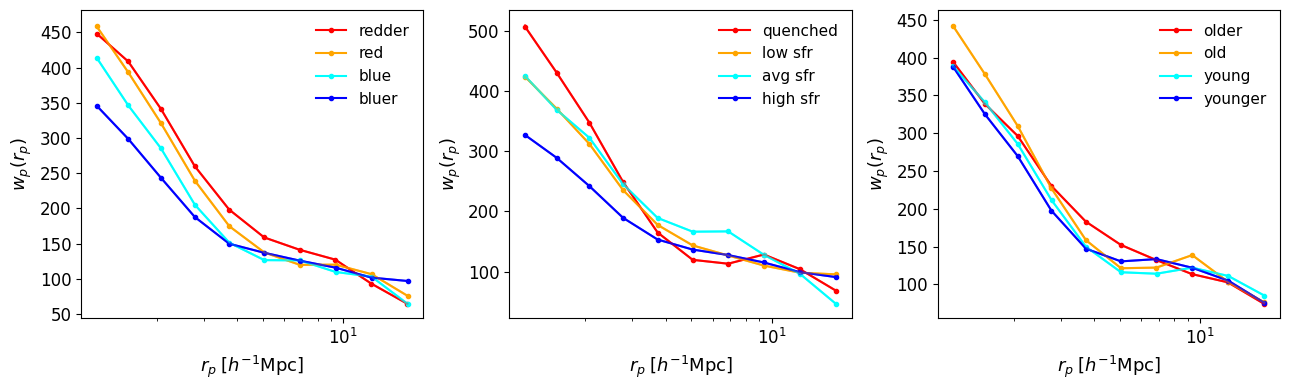

In [47]:
# plot
fig,ax = plt.subplots(1,3, figsize=(13, 4))

ax[0].plot(ptpcf_red_50[0],ptpcf_red_50[1], marker = '.',color= 'Red', label = 'redder')
ax[0].plot(ptpcf_midred_50[0],ptpcf_midred_50[1], marker = '.', color= 'Orange', label = 'red')
ax[0].plot(ptpcf_midblue_50[0],ptpcf_midblue_50[1], marker = '.',color= 'Cyan', label = 'blue')
ax[0].plot(ptpcf_blue_50[0],ptpcf_blue_50[1], marker = '.', color= 'Blue', label = 'bluer')

ax[0].errorbar(ptpcf_red_50[0], ptpcf_red_50[1], yerr=uncertain_red_50[1], color= 'Red', alpha = .5)
ax[0].errorbar(ptpcf_midred_50[0], ptpcf_midred_50[1], yerr=uncertain_midred_50[1], color= 'Orange', alpha = .5)
ax[0].errorbar(ptpcf_midblue_50[0], ptpcf_midblue_50[1], yerr=uncertain_midblue_50[1], color= 'Cyan', alpha = .5)
ax[0].errorbar(ptpcf_blue_50[0], ptpcf_blue_50[1], yerr=uncertain_blue_50[1], color= 'Blue', alpha = .5)

ax[0].set_xlabel(r"$r_{p} \; [h^{-1} \mathrm{Mpc}]$", fontsize=13)
ax[0].set_ylabel(r"$w_{p} (r_{p})$", fontsize=13)
#ax[0].set_title('projected tpcf', fontsize=11)
#ax[0].set_ylim(0,2.5)
#ax[0].set_xlim(10e-1,10**(1.3))
#ax[0].set_yticks(np.arange(0,50,10))
ax[0].set_xscale('log')
ax[0].legend(fontsize=11, frameon=False)


ax[1].plot(ptpcf_quenched_50[0],ptpcf_quenched_50[1], marker = '.', color= 'Red', label = 'quenched')
ax[1].plot(ptpcf_midquenched_50[0],ptpcf_midquenched_50[1], marker = '.', color= 'Orange', label = 'low sfr')
ax[1].plot(ptpcf_midstarform_50[0],ptpcf_midstarform_50[1], marker = '.', color= 'Cyan', label = 'avg sfr')
ax[1].plot(ptpcf_starform_50[0],ptpcf_starform_50[1], marker = '.', color= 'Blue', label = 'high sfr')

ax[1].errorbar(ptpcf_quenched_50[0], ptpcf_quenched_50[1], yerr=uncertain_quenched_50[1], color= 'Red', alpha = .5)
ax[1].errorbar(ptpcf_midquenched_50[0], ptpcf_midquenched_50[1], yerr=uncertain_midquenched_50[1], color= 'Orange', alpha = .5)
ax[1].errorbar(ptpcf_midstarform_50[0], ptpcf_midstarform_50[1], yerr=uncertain_midstarform_50[1], color= 'Cyan', alpha = .5)
ax[1].errorbar(ptpcf_starform_50[0], ptpcf_starform_50[1], yerr=uncertain_starform_50[1], color= 'Blue', alpha = .5)

ax[1].set_xlabel(r"$r_{p} \; [h^{-1} \mathrm{Mpc}]$",fontsize=13)
ax[1].set_ylabel(r"$w_{p} (r_{p})$",fontsize=13)
#ax[1].set_title('projected tpcf', fontsize=11)
#ax[1].set_ylim(0,2.5)
#ax[1].set_xlim(10e-1,10**(1.3))
#ax[1].set_yticks(np.arange(0,55,10))
ax[1].set_xscale('log')
ax[1].legend(fontsize=11, frameon=False)


ax[2].plot(ptpcf_old_50[0],ptpcf_old_50[1], marker = '.', color= 'Red', label = 'older')
ax[2].plot(ptpcf_midold_50[0],ptpcf_midold_50[1], marker = '.', color= 'Orange', label = 'old')
ax[2].plot(ptpcf_midyoung_50[0],ptpcf_midyoung_50[1], marker = '.', color= 'Cyan', label = 'young')
ax[2].plot(ptpcf_young_50[0],ptpcf_young_50[1], marker = '.', color= 'Blue', label = 'younger')

ax[2].errorbar(ptpcf_old_50[0], ptpcf_old_50[1], yerr=uncertain_old_50[1], color= 'Red', alpha = .5)
ax[2].errorbar(ptpcf_midold_50[0], ptpcf_midold_50[1], yerr=uncertain_midold_50[1], color= 'Orange', alpha = .5)
ax[2].errorbar(ptpcf_midyoung_50[0], ptpcf_midyoung_50[1], yerr=uncertain_midyoung_50[1], color= 'Cyan', alpha = .5)
ax[2].errorbar(ptpcf_young_50[0], ptpcf_young_50[1], yerr=uncertain_young_50[1], color= 'Blue', alpha = .5)

ax[2].set_xlabel(r"$r_{p} \; [h^{-1} \mathrm{Mpc}]$", fontsize=13)
ax[2].set_ylabel(r"$w_{p} (r_{p})$", fontsize=13)
#ax[2].set_title('projected 2pcf', fontsize=11)
#ax[2].set_ylim(15,70)
#ax[2].set_xlim(10e-1,10**(0.1))
#ax[2].set_yticks(np.arange(0,50,10))
ax[2].set_xscale('log')
ax[2].legend(fontsize=11, frameon=False)

for i in range(3):
        ax[i].tick_params(labelsize=12)

plt.tight_layout()
plt.rc('pgf', texsystem='pdflatex')

### 10 chunks

In [48]:
n = 10

In [49]:
# projected 2pcf with bootstrap uncertainty

# Color-dependent
ptpcf_red_50 = calculate_projected_2pcf_split(
    large_positions= np.array([pos for gal,pos in new_gal_pos if gal in more2]),
    boxsize= obj.simulation.boxsize,
    binnum=10,
    N=n
)
ptpcf_midred_50 = calculate_projected_2pcf_split(
    large_positions= np.array([pos for gal,pos in new_gal_pos if gal in midmore2]),
    boxsize= obj.simulation.boxsize,
    binnum=10,
    N=n
)
ptpcf_midblue_50 = calculate_projected_2pcf_split(
    large_positions= np.array([pos for gal,pos in new_gal_pos if gal in midless2]),
    boxsize= obj.simulation.boxsize,
    binnum=10,
    N=n
)
ptpcf_blue_50 = calculate_projected_2pcf_split(
    large_positions= np.array([pos for gal,pos in new_gal_pos if gal in less2]),
    boxsize= obj.simulation.boxsize,
    binnum=10,
    N=n
)

# sSFR-dependent
ptpcf_starform_50 = calculate_projected_2pcf_split(
    large_positions= np.array([pos for gal,pos in new_gal_pos if gal in more3]),
    boxsize= obj.simulation.boxsize,
    binnum=10,
    N=n
)
ptpcf_midstarform_50 = calculate_projected_2pcf_split(
    large_positions= np.array([pos for gal,pos in new_gal_pos if gal in midmore3]),
    boxsize= obj.simulation.boxsize,
    binnum=10,
    N=n
)
ptpcf_midquenched_50 = calculate_projected_2pcf_split(
    large_positions= np.array([pos for gal,pos in new_gal_pos if gal in midless3]),
    boxsize= obj.simulation.boxsize,
    binnum=10,
    N=n
)
ptpcf_quenched_50 = calculate_projected_2pcf_split(
    large_positions= np.array([pos for gal,pos in new_gal_pos if gal in less3]),
    boxsize= obj.simulation.boxsize,
    binnum=10,
    N=n
)

# Age-dependent
ptpcf_old_50 = calculate_projected_2pcf_split(
    large_positions= np.array([pos for gal,pos in new_gal_pos if gal in more1]),
    boxsize= obj.simulation.boxsize,
    binnum=10,
    N=n
)
ptpcf_midold_50 = calculate_projected_2pcf_split(
    large_positions= np.array([pos for gal,pos in new_gal_pos if gal in midmore1]),
    boxsize= obj.simulation.boxsize,
    binnum=10,
    N=n
)
ptpcf_midyoung_50 = calculate_projected_2pcf_split(
    large_positions= np.array([pos for gal,pos in new_gal_pos if gal in midless1]),
    boxsize= obj.simulation.boxsize,
    binnum=10,
    N=n
)
ptpcf_young_50 = calculate_projected_2pcf_split(
    large_positions= np.array([pos for gal,pos in new_gal_pos if gal in less1]),
    boxsize= obj.simulation.boxsize,
    binnum=10,
    N=n
)

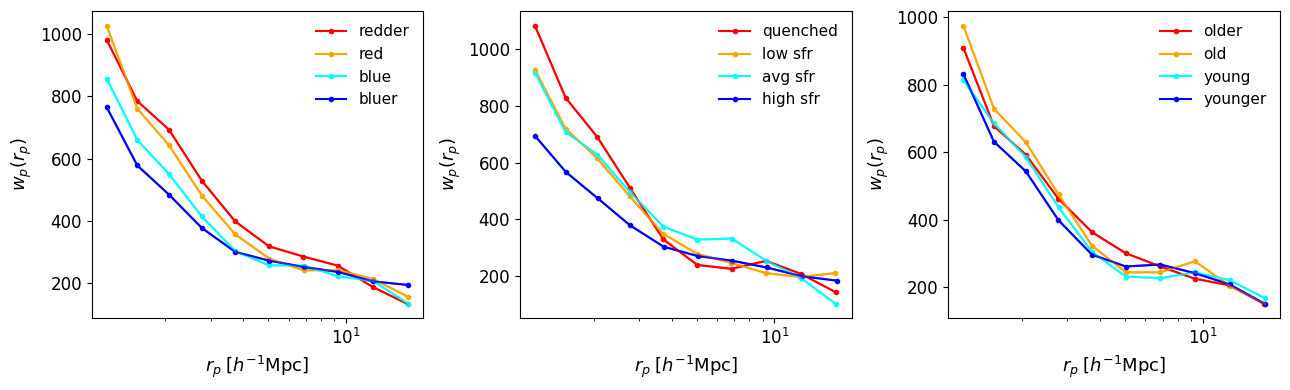

In [50]:
# plot
fig,ax = plt.subplots(1,3, figsize=(13, 4))

ax[0].plot(ptpcf_red_50[0],ptpcf_red_50[1], marker = '.',color= 'Red', label = 'redder')
ax[0].plot(ptpcf_midred_50[0],ptpcf_midred_50[1], marker = '.', color= 'Orange', label = 'red')
ax[0].plot(ptpcf_midblue_50[0],ptpcf_midblue_50[1], marker = '.',color= 'Cyan', label = 'blue')
ax[0].plot(ptpcf_blue_50[0],ptpcf_blue_50[1], marker = '.', color= 'Blue', label = 'bluer')

ax[0].errorbar(ptpcf_red_50[0], ptpcf_red_50[1], yerr=uncertain_red_50[1], color= 'Red', alpha = .5)
ax[0].errorbar(ptpcf_midred_50[0], ptpcf_midred_50[1], yerr=uncertain_midred_50[1], color= 'Orange', alpha = .5)
ax[0].errorbar(ptpcf_midblue_50[0], ptpcf_midblue_50[1], yerr=uncertain_midblue_50[1], color= 'Cyan', alpha = .5)
ax[0].errorbar(ptpcf_blue_50[0], ptpcf_blue_50[1], yerr=uncertain_blue_50[1], color= 'Blue', alpha = .5)

ax[0].set_xlabel(r"$r_{p} \; [h^{-1} \mathrm{Mpc}]$", fontsize=13)
ax[0].set_ylabel(r"$w_{p} (r_{p})$", fontsize=13)
#ax[0].set_title('projected tpcf', fontsize=11)
#ax[0].set_ylim(0,2.5)
#ax[0].set_xlim(10e-1,10**(1.3))
#ax[0].set_yticks(np.arange(0,50,10))
ax[0].set_xscale('log')
ax[0].legend(fontsize=11, frameon=False)


ax[1].plot(ptpcf_quenched_50[0],ptpcf_quenched_50[1], marker = '.', color= 'Red', label = 'quenched')
ax[1].plot(ptpcf_midquenched_50[0],ptpcf_midquenched_50[1], marker = '.', color= 'Orange', label = 'low sfr')
ax[1].plot(ptpcf_midstarform_50[0],ptpcf_midstarform_50[1], marker = '.', color= 'Cyan', label = 'avg sfr')
ax[1].plot(ptpcf_starform_50[0],ptpcf_starform_50[1], marker = '.', color= 'Blue', label = 'high sfr')

ax[1].errorbar(ptpcf_quenched_50[0], ptpcf_quenched_50[1], yerr=uncertain_quenched_50[1], color= 'Red', alpha = .5)
ax[1].errorbar(ptpcf_midquenched_50[0], ptpcf_midquenched_50[1], yerr=uncertain_midquenched_50[1], color= 'Orange', alpha = .5)
ax[1].errorbar(ptpcf_midstarform_50[0], ptpcf_midstarform_50[1], yerr=uncertain_midstarform_50[1], color= 'Cyan', alpha = .5)
ax[1].errorbar(ptpcf_starform_50[0], ptpcf_starform_50[1], yerr=uncertain_starform_50[1], color= 'Blue', alpha = .5)

ax[1].set_xlabel(r"$r_{p} \; [h^{-1} \mathrm{Mpc}]$",fontsize=13)
ax[1].set_ylabel(r"$w_{p} (r_{p})$",fontsize=13)
#ax[1].set_title('projected tpcf', fontsize=11)
#ax[1].set_ylim(0,2.5)
#ax[1].set_xlim(10e-1,10**(1.3))
#ax[1].set_yticks(np.arange(0,55,10))
ax[1].set_xscale('log')
ax[1].legend(fontsize=11, frameon=False)


ax[2].plot(ptpcf_old_50[0],ptpcf_old_50[1], marker = '.', color= 'Red', label = 'older')
ax[2].plot(ptpcf_midold_50[0],ptpcf_midold_50[1], marker = '.', color= 'Orange', label = 'old')
ax[2].plot(ptpcf_midyoung_50[0],ptpcf_midyoung_50[1], marker = '.', color= 'Cyan', label = 'young')
ax[2].plot(ptpcf_young_50[0],ptpcf_young_50[1], marker = '.', color= 'Blue', label = 'younger')

ax[2].errorbar(ptpcf_old_50[0], ptpcf_old_50[1], yerr=uncertain_old_50[1], color= 'Red', alpha = .5)
ax[2].errorbar(ptpcf_midold_50[0], ptpcf_midold_50[1], yerr=uncertain_midold_50[1], color= 'Orange', alpha = .5)
ax[2].errorbar(ptpcf_midyoung_50[0], ptpcf_midyoung_50[1], yerr=uncertain_midyoung_50[1], color= 'Cyan', alpha = .5)
ax[2].errorbar(ptpcf_young_50[0], ptpcf_young_50[1], yerr=uncertain_young_50[1], color= 'Blue', alpha = .5)

ax[2].set_xlabel(r"$r_{p} \; [h^{-1} \mathrm{Mpc}]$", fontsize=13)
ax[2].set_ylabel(r"$w_{p} (r_{p})$", fontsize=13)
#ax[2].set_title('projected 2pcf', fontsize=11)
#ax[2].set_ylim(15,70)
#ax[2].set_xlim(10e-1,10**(0.1))
#ax[2].set_yticks(np.arange(0,50,10))
ax[2].set_xscale('log')
ax[2].legend(fontsize=11, frameon=False)

for i in range(3):
        ax[i].tick_params(labelsize=12)

plt.tight_layout()
plt.rc('pgf', texsystem='pdflatex')